In [1]:
from pathlib import Path
import copy
import os
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import MinMaxScaler
from torch import nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(min(8, os.cpu_count() or 1))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [2]:
data_path = Path("household_power_consumption.txt")

if not data_path.exists():
    raise FileNotFoundError(
        "Place household_power_consumption.txt in the same folder as this notebook."
    )

sensor_cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

dtypes = {col: "float32" for col in sensor_cols}

df = pd.read_csv(
    data_path,
    sep=";",
    na_values="?",
    usecols=["Date", "Time"] + sensor_cols,
    dtype=dtypes,
    low_memory=False
)

df["datetime"] = pd.to_datetime(
    df.pop("Date") + " " + df.pop("Time"),
    format="%d/%m/%Y %H:%M:%S"
)

df = df.set_index("datetime").sort_index()

missing_count = int(df.isna().sum().sum())
missing_pct = 100 * missing_count / df.size

mask = df["Global_active_power"].isna().to_numpy()
changes = np.diff(np.r_[False, mask, False].astype(int))
starts = np.where(changes == 1)[0]
ends = np.where(changes == -1)[0]
max_gap = int((ends - starts).max()) if len(starts) else 0

hourly = df.resample("h").mean()
coverage = df["Global_active_power"].resample("h").count()

low_coverage = coverage < 45
hourly.loc[low_coverage, sensor_cols] = np.nan
observed_target = (~low_coverage) & hourly["Global_active_power"].notna()

TEST_START = hourly.index.max() - pd.DateOffset(months=6)
VAL_START = TEST_START - pd.DateOffset(months=3)
train_rows = hourly.index < VAL_START

hourly[sensor_cols] = hourly[sensor_cols].ffill(limit=3)

hour_of_week = pd.Series(
    hourly.index.dayofweek * 24 + hourly.index.hour,
    index=hourly.index
)

for col in sensor_cols:
    medians = hourly.loc[train_rows, col].groupby(
        hour_of_week.loc[train_rows]
    ).median()

    missing = hourly[col].isna()
    hourly.loc[missing, col] = hour_of_week.loc[missing].map(medians)
    hourly[col] = hourly[col].fillna(
        hourly.loc[train_rows, col].median()
    )

print("Rows:", f"{len(df):,}")
print("Missing values:", f"{missing_count:,} ({missing_pct:.4f}%)")
print("Longest missing gap:", f"{max_gap:,} minutes")
print("Hourly rows:", f"{len(hourly):,}")
print(
    "Remaining missing values:",
    int(hourly[sensor_cols].isna().sum().sum())
)
print("Train:", hourly.index.min(), "to", VAL_START)
print("Validation:", VAL_START, "to", TEST_START)
print("Test:", TEST_START, "to", hourly.index.max())

hourly.to_csv("Assignment06_hourly_cleaned.csv")

Rows: 2,075,259
Missing values: 181,853 (1.2518%)
Longest missing gap: 7,226 minutes
Hourly rows: 34,589
Remaining missing values: 0
Train: 2006-12-16 17:00:00 to 2010-02-26 21:00:00
Validation: 2010-02-26 21:00:00 to 2010-05-26 21:00:00
Test: 2010-05-26 21:00:00 to 2010-11-26 21:00:00


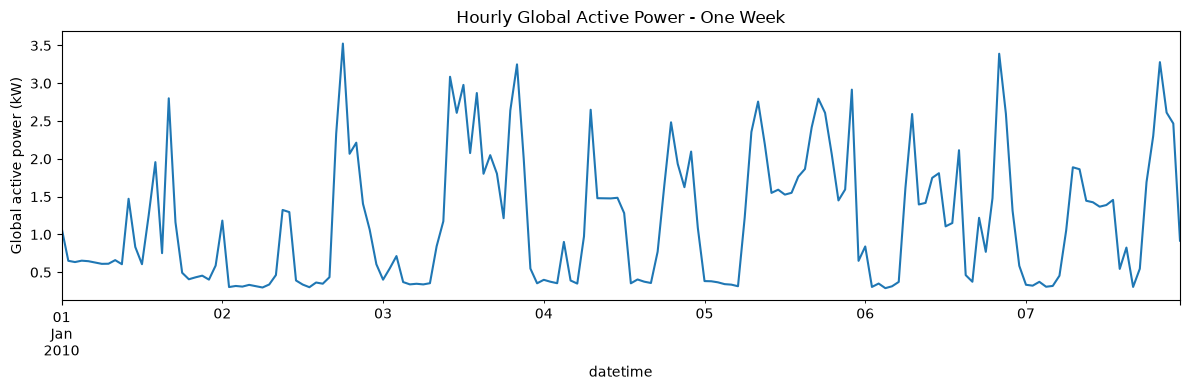

In [3]:
hourly.loc[
    "2010-01-01":"2010-01-07",
    "Global_active_power"
].plot(figsize=(12, 4))

plt.title("Hourly Global Active Power - One Week")
plt.ylabel("Global active power (kW)")
plt.tight_layout()
plt.show()

In [4]:
idx = hourly.index

hourly["hour_sin"] = np.sin(2 * np.pi * idx.hour / 24)
hourly["hour_cos"] = np.cos(2 * np.pi * idx.hour / 24)
hourly["dow_sin"] = np.sin(2 * np.pi * idx.dayofweek / 7)
hourly["dow_cos"] = np.cos(2 * np.pi * idx.dayofweek / 7)
hourly["year_sin"] = np.sin(2 * np.pi * idx.dayofyear / 365.25)
hourly["year_cos"] = np.cos(2 * np.pi * idx.dayofyear / 365.25)

feature_cols = sensor_cols + [
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "year_sin",
    "year_cos"
]

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

feature_scaler.fit(hourly.loc[train_rows, feature_cols])
target_scaler.fit(
    np.log1p(hourly.loc[train_rows, ["Global_active_power"]])
)

X_all = feature_scaler.transform(
    hourly[feature_cols]
).astype(np.float32)

y_all = target_scaler.transform(
    np.log1p(hourly[["Global_active_power"]])
).astype(np.float32).ravel()

LOOKBACK = 168
HORIZON = 24

all_starts = np.arange(
    LOOKBACK,
    len(hourly) - HORIZON + 1
)

forecast_start = hourly.index[all_starts]
forecast_end = hourly.index[all_starts + HORIZON - 1]

observed = observed_target.to_numpy()

complete_target = np.array([
    observed[i:i + HORIZON].all()
    for i in all_starts
])

train_starts = all_starts[
    (forecast_end < VAL_START) & complete_target
][::12]

val_starts = all_starts[
    (forecast_start >= VAL_START)
    & (forecast_end < TEST_START)
    & complete_target
][::24]

test_starts = all_starts[
    (forecast_start >= TEST_START) & complete_target
][::24]

print("Training windows:", len(train_starts))
print("Validation windows:", len(val_starts))
print("Test windows:", len(test_starts))

Training windows: 2284
Validation windows: 86
Test windows: 173


In [5]:
class WindowDataset(Dataset):
    def __init__(self, X, y, starts):
        self.X = X
        self.y = y
        self.starts = np.asarray(starts, dtype=np.int64)

    def __len__(self):
        return len(self.starts)

    def __getitem__(self, index):
        i = int(self.starts[index])

        return (
            torch.from_numpy(self.X[i - LOOKBACK:i]),
            torch.from_numpy(self.y[i:i + HORIZON])
        )


train_loader = DataLoader(
    WindowDataset(X_all, y_all, train_starts),
    batch_size=256,
    shuffle=True
)

val_loader = DataLoader(
    WindowDataset(X_all, y_all, val_starts),
    batch_size=512,
    shuffle=False
)

test_loader = DataLoader(
    WindowDataset(X_all, y_all, test_starts),
    batch_size=512,
    shuffle=False
)

In [6]:
class LSTMForecast(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size=64,
        horizon=HORIZON
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            batch_first=True
        )

        self.head = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(64, horizon)
        )

    def forward(self, x):
        _, (hidden, _) = self.lstm(x)
        return self.head(hidden[-1])


model = LSTMForecast(len(feature_cols)).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=7e-4,
    weight_decay=1e-5
)

loss_fn = nn.SmoothL1Loss(beta=0.05)

In [7]:
def train_epoch(loader):
    model.train()
    total = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        loss = loss_fn(model(X_batch), y_batch)
        loss.backward()

        nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()
        total += loss.item() * X_batch.size(0)

    return total / len(loader.dataset)


@torch.no_grad()
def validation_loss(loader):
    model.eval()
    total = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        total += (
            loss_fn(model(X_batch), y_batch).item()
            * X_batch.size(0)
        )

    return total / len(loader.dataset)


best_state = None
best_loss = np.inf
wait = 0

for epoch in range(1, 9):
    start = time.perf_counter()

    train_loss = train_epoch(train_loader)
    val_loss = validation_loss(val_loader)

    print(
        f"Epoch {epoch:02d} | "
        f"train {train_loss:.4f} | "
        f"validation {val_loss:.4f} | "
        f"{time.perf_counter() - start:.1f}s"
    )

    if val_loss < best_loss - 1e-4:
        best_loss = val_loss
        best_state = copy.deepcopy(
            model.state_dict()
        )
        wait = 0
    else:
        wait += 1

        if wait >= 5:
            break

if best_state is not None:
    model.load_state_dict(best_state)

Epoch 01 | train 0.2407 | validation 0.2045 | 1.0s
Epoch 02 | train 0.1941 | validation 0.1418 | 1.0s
Epoch 03 | train 0.1566 | validation 0.1289 | 0.9s
Epoch 04 | train 0.1408 | validation 0.1263 | 0.9s
Epoch 05 | train 0.1353 | validation 0.1264 | 0.9s
Epoch 06 | train 0.1324 | validation 0.1240 | 0.9s
Epoch 07 | train 0.1306 | validation 0.1241 | 0.9s
Epoch 08 | train 0.1293 | validation 0.1242 | 0.9s


In [8]:
@torch.no_grad()
def predict(loader):
    model.eval()
    predictions = []
    actuals = []

    for X_batch, y_batch in loader:
        predictions.append(
            model(X_batch.to(device)).cpu().numpy()
        )
        actuals.append(y_batch.numpy())

    return (
        np.vstack(predictions),
        np.vstack(actuals)
    )


pred_scaled, actual_scaled = predict(test_loader)

pred_log = target_scaler.inverse_transform(
    pred_scaled.reshape(-1, 1)
).reshape(pred_scaled.shape)

actual_log = target_scaler.inverse_transform(
    actual_scaled.reshape(-1, 1)
).reshape(actual_scaled.shape)

predicted = np.clip(
    np.expm1(pred_log),
    0,
    None
)

actual = np.expm1(actual_log)

mape = np.mean(
    np.abs(
        (actual - predicted)
        / np.maximum(np.abs(actual), 1e-3)
    )
) * 100

mae = np.mean(
    np.abs(actual - predicted)
)

rmse = np.sqrt(
    np.mean((actual - predicted) ** 2)
)

results = pd.DataFrame({
    "Metric": ["MAPE", "MAE", "RMSE"],
    "Value": [mape, mae, rmse]
})

print(results.to_string(index=False))
print("MAPE requirement met:", mape <= 10)

Metric     Value
  MAPE 73.368843
   MAE  0.552784
  RMSE  0.761956
MAPE requirement met: False


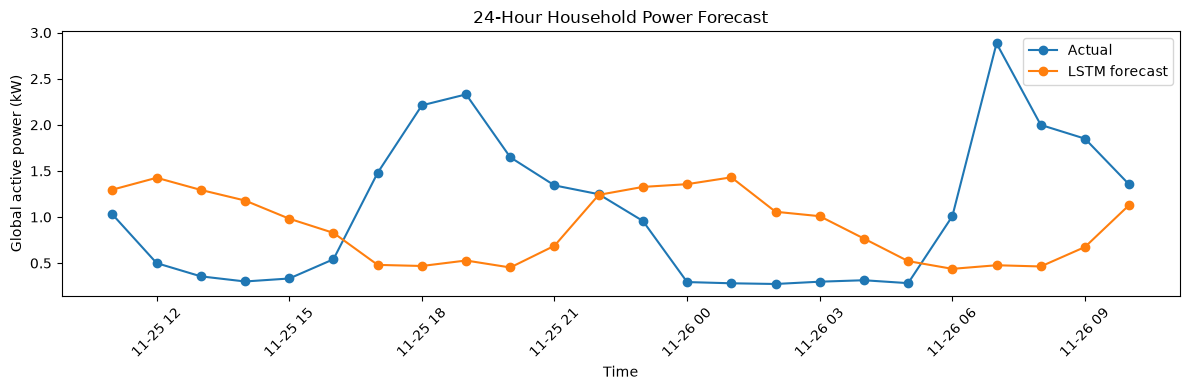

In [9]:
sample = -1
sample_start = hourly.index[test_starts[sample]]

hours = pd.date_range(
    sample_start,
    periods=HORIZON,
    freq="h"
)

plt.figure(figsize=(12, 4))
plt.plot(
    hours,
    actual[sample],
    marker="o",
    label="Actual"
)
plt.plot(
    hours,
    predicted[sample],
    marker="o",
    label="LSTM forecast"
)

plt.title("24-Hour Household Power Forecast")
plt.xlabel("Time")
plt.ylabel("Global active power (kW)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()